Fundamentals of Deep Learning Models

# Lab 08-3: Sequence Model with GRU
## Exercise: Sentiment analysis of movie reviews

This exercise builds a **sentiment classifier** for the IMDB movie review dataset
using a **Bidirectional GRU** (Sections 8.6 and 8.8) with learned word embeddings
(Section 8.7). The model predicts whether a review expresses a positive or negative
sentiment (binary classification).

Key components from the textbook:
- **Embedding layer** (Section 8.7): Maps integer word indices to dense vectors.
- **GRU** (Section 8.6, Eqs. 8.30–8.33): A gated recurrent unit that uses reset and update gates.
- **Bidirectional RNN** (Section 8.8): Processes the sequence in both forward and backward directions.
- **Dropout** (Section 8.9): Regularization to mitigate overfitting in recurrent models.

Reference: Adapted from the TensorFlow text classification tutorial
(https://www.tensorflow.org/text/tutorials/text_classification_rnn), licensed under Apache 2.0.

### Import libraries

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('TensorFlow Datasets version:', tfds.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
TensorFlow Datasets version: 4.9.9
Matplotlib version: 3.10.0
Num GPUs Available:  1


### Load IMDB dataset

The IMDB movie review dataset contains 25,000 training and 25,000 test reviews,
each labeled as positive (1) or negative (0). The reviews are variable-length
text sequences that must be tokenized and padded before being fed to the RNN.

In [2]:
# Load IMDB reviews dataset (publicly available via TensorFlow Datasets)
(ds_train, ds_test), ds_info = tfds.load('imdb_reviews',
                                         split=['train', 'test'],
                                         shuffle_files=True,
                                         as_supervised=True,
                                         with_info=True)

print(ds_info.features)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.I8W2RM_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.I8W2RM_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.I8W2RM_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
FeaturesDict({
    'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    'text': Text(shape=(), dtype=string),
})


In [3]:
# Extract text and labels from the dataset
X_train = []
y_train = []
X_test_str = []
y_test = []

for sentence, label in ds_train:
    X_train.append(sentence.numpy().decode('utf8'))
    y_train.append(label.numpy())

for sentence, label in ds_test:
    X_test_str.append(sentence.numpy().decode('utf8'))
    y_test.append(label.numpy())

y_train = np.array(y_train)
y_test = np.array(y_test)

In [4]:
# Display a sample review
print(X_train[0])
print('The review is', 'Positive' if y_train[0]==1 else 'Negative')

This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
The review is Negative


### Tokenization and integer encoding

Text data must be converted to numerical form before processing.
A `Tokenizer` maps each word to an integer index (keeping the top `vocab_size` words).
Sequences are then padded or truncated to a uniform length `max_length`,
as required by mini-batch training (Section 8.9).

- `vocab_size = 10000`: Only the 10,000 most frequent words are retained.
- `max_length = 300`: Sequences shorter than 300 are zero-padded; longer ones are truncated.
- `embedding_size = 128`: Each word is mapped to a 128-dimensional dense vector (Section 8.7).

In [ ]:
# Hyperparameters for text preprocessing and embedding
vocab_size = 10000
embedding_size = 128
max_length = 300

### START CODE HERE ###

# Build tokenizer on training data: maps words to integer IDs
tokenizer = keras.preprocessing....
tokenizer.fit_on_texts(...)
word_index = None

# Convert text to integer sequences
X_train = tokenizer....
X_test  = tokenizer....

# Pad/truncate sequences to uniform length (Section 8.9: padding and masking)
X_train = keras.preprocessing....
X_test  = keras.preprocessing....

### END CODE HERE ###

### Model definition

The model architecture is:

1. **Embedding** (`vocab_size` $\to$ `embedding_size`): Learns dense word representations (Section 8.7).
2. **Bidirectional GRU** (Section 8.8 + Section 8.6): Processes the sequence in both directions.
   Each GRU cell implements the gating mechanism with reset gate $\mathbf{r}_t$ (Eq. 8.30),
   hidden state candidate $\widetilde{\mathbf{h}}_t$ (Eq. 8.31), update gate $\mathbf{z}_t$ (Eq. 8.32),
   and state update $\mathbf{h}_t$ (Eq. 8.33). The bidirectional wrapper concatenates the forward
   and backward hidden states, producing an output of dimension $2 \times n_h$ (Section 8.8).
3. **Dropout** (`rate=0.5`): Regularization for recurrent models (Section 8.9).
4. **Dense** (sigmoid): Binary classification output for positive/negative sentiment.

#### Network analysis assignment
Derive how the **Param #** values in the model summary below are computed.

In [ ]:
hidden_states = 64
dropout_rate = 0.5

model = keras.Sequential()

### START CODE HERE ###

# Input layer: integer sequences of length max_length
model.add(keras.layers....)

# Embedding: map word IDs to dense vectors (Section 8.7)
model.add(keras.layers....)

# Bidirectional GRU: forward + backward GRU (Sections 8.6, 8.8, Eqs. 8.30-8.33)
model.add(keras.layers....)

# Dropout: regularization to reduce overfitting (Section 8.9)
model.add(keras.layers....)

# Dense output: sigmoid for binary classification
model.add(keras.layers....)

### END CODE HERE ###

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,354,625 (5.17 MB)

 Trainable params: 1,354,625 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

**Expected model summary:**

| Layer | Output Shape | Param # |
|-------|-------------|---------|
| Embedding | (None, 300, 128) | 1,280,000 |
| Bidirectional (GRU) | (None, 128) | 74,496 |
| Dropout | (None, 128) | 0 |
| Dense | (None, 1) | 129 |

**Total params:** 1,354,625

### Training

The model is trained with binary cross-entropy loss and the Adam optimizer (Section 4.3).
Early stopping monitors validation loss to prevent overfitting,
and model checkpointing saves the best model based on validation accuracy.

In [7]:
n_batch = 64

# Early stopping: stop if val_loss does not improve for 4 epochs
es = keras.callbacks.EarlyStopping(
    monitor='val_loss', mode='min', verbose=1, patience=4)

# Model checkpoint: save best model by val_accuracy
mc = keras.callbacks.ModelCheckpoint(
    'GRU_imdb.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

results = model.fit(X_train, y_train,
                    batch_size=n_batch,
                    epochs=10,
                    callbacks=[es, mc],
                    validation_split=0.2)

print(results.history['loss'])
print(results.history['accuracy'])

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6098 - loss: 0.6340
Epoch 1: val_accuracy improved from None to 0.82160, saving model to GRU_imdb.keras

Epoch 1: finished saving model to GRU_imdb.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7010 - loss: 0.5571 - val_accuracy: 0.8216 - val_loss: 0.4104
Epoch 2/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8581 - loss: 0.3519
Epoch 2: val_accuracy improved from 0.82160 to 0.83760, saving model to GRU_imdb.keras

Epoch 2: finished saving model to GRU_imdb.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8646 - loss: 0.3354 - val_accuracy: 0.8376 - val_loss: 0.3974
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9102 - loss: 0.2406
Epoch 3: val_accuracy did not improve from 0.83760
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9082 - loss: 0.2454 - val_accuracy: 0.8220 - val_loss: 0.3995
Epoch 4/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accurac

### Plot convergence

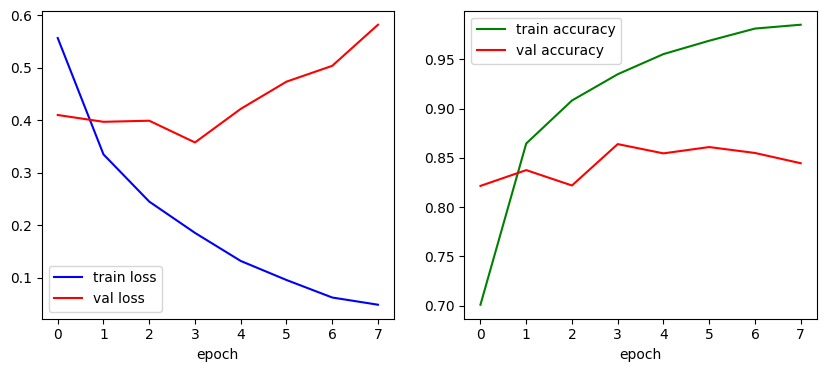

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(results.history['loss'], 'b-', label='train loss')
plt.plot(results.history['val_loss'], 'r-', label='val loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results.history['accuracy'], 'g-', label='train accuracy')
plt.plot(results.history['val_accuracy'], 'r-', label='val accuracy')
plt.xlabel('epoch')
plt.legend()

plt.show()

### Evaluate on test set

In [9]:
model.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8264 - loss: 0.6573


[0.6572678685188293, 0.8263999819755554]

### Test model with a random review

In [10]:
idx = np.random.randint(X_test.shape[0])

X_input = X_test[idx].reshape(1, -1)
score = float(model.predict(X_input)[0][0])

decision = 1 if score > 0.5 else 0
rate = score if decision == 1 else (1 - score)

print(X_test_str[idx])
print('The review is', 'Positive' if decision == 1 else 'Negative',
      'with {:.2f}% confidence'.format(rate * 100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
It is a risky business to film such a lavish production of "The Merchant of Venice". It could be a stodgy, wooden, period piece, or it could be laughable for its excesses. This version is neither. While I am not completely sold by Al Pancino's very restrained Shylock, he does give a competent and honorable performance. Jeremy Iron's Antonio, is as always with his tortured-self roles, riveting. Some of the lesser roles seemed to be a little to much in the spirit of boisterous fun, "a boy's own Venician adventure story", but the central plot is efficiently and sympathetically moved forward through the film.<br /><br />It goes without saying, that the location shots, costumes, and interiors were breathtaking, almost to the point of distraction.<br /><br />One thing, on which I do not wish to comment on, is the anti-semetic content of the play. The film is as sympathetic to the predicament of the Jews as possible while still portraying Shylock as the 

(c) 2026 S. W. Lee